In [30]:
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, KFold

## Оптмизиаця признакового пространства

In [31]:
data = pd.read_csv("../data/processed_smoke_detector.csv")
X = data.drop(labels=["Fire Alarm"], axis=1)
y = data["Fire Alarm"]

In [32]:
from sklearn.feature_selection import SelectKBest

In [33]:
skb = SelectKBest(k=2)
X_skb = skb.fit_transform(X, y)
X_skb = pd.DataFrame(X_skb, columns=skb.get_feature_names_out())
X_skb.head()

,TVOC[ppb],Raw Ethanol
0,19.0,19951.0
1,1.0,19975.0
2,10.0,19955.0
3,10.0,19963.0
4,13.0,19958.0


In [34]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [35]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_skb, y, test_size=0.2, random_state=42)

## Sklearn MLP

In [7]:
import numpy as np
import optuna
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from scipy.stats import loguniform
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

### RandomSearch

In [8]:
param_dist = {
    'hidden_layer_sizes': [(32,), (64,), (32,32), (64,32), (64,64)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'alpha': loguniform(1e-3, 1e-1),
    'learning_rate_init': loguniform(1e-3, 0.1),
    'batch_size': [16, 32, 64, 128]
}

mlp = MLPClassifier(max_iter=100, random_state=42)

random_search = RandomizedSearchCV(mlp, param_dist, n_iter=10, cv=5, scoring='f1', n_jobs=-1)
random_search.fit(X_train_clf, y_train_clf)

print("RandomizedSearchCV results:")
print(f"Best params: {random_search.best_params_}")
print(f"Best CV accuracy: {random_search.best_score_:.4f}")
print(f"Test accuracy: {random_search.score(X_test_clf, y_test_clf):.4f}")


RandomizedSearchCV results:
Best params: {'activation': 'tanh', 'alpha': 0.010871651672879528, 'batch_size': 64, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.0015913652792979266, 'solver': 'lbfgs'}
Best CV accuracy: 0.9302
Test accuracy: 0.9231


## Optuna

In [ ]:
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_layer_sizes = []
    for i in range(n_layers):
        neurons = trial.suggest_int(f'neurons_layer{i}', 32, 256, step=32)
        hidden_layer_sizes.append(neurons)
    
    params = {
        'hidden_layer_sizes': tuple(hidden_layer_sizes),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        'solver': trial.suggest_categorical('solver', ['adam', 'sgd', 'lbfgs']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 0.1, log=True),
        'batch_size': trial.suggest_int('batch_size', 16, 128, step=16),
        'max_iter': trial.suggest_int('max_iter', 200, 1000, step=100),
        'early_stopping': trial.suggest_categorical('early_stopping', [True, False]),
        'random_state': 42
    }
    
    model = MLPClassifier(**params)
    scores = cross_val_score(model, X_train_clf, y_train_clf, 
                           cv=5, scoring='accuracy', n_jobs=-1)
    return np.mean(scores)

study = optuna.create_study(direction='maximize',
                           sampler=optuna.samplers.TPESampler(),
                           pruner=optuna.pruners.HyperbandPruner())
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best trial:")
trial = study.best_trial
print(f"  Value (Accuracy): {trial.value:.4f}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-06-06 23:57:08,921] A new study created in memory with name: no-name-8e4e6ada-8cc1-4758-8a18-56519e8bf55d


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-06-06 23:57:10,115] Trial 0 finished with value: 0.7819498730294306 and parameters: {'n_layers': 1, 'neurons_layer0': 32, 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 0.0907844730856697, 'learning_rate_init': 0.004465882251650786, 'batch_size': 96, 'max_iter': 900, 'early_stopping': True}. Best is trial 0 with value: 0.7819498730294306.
[I 2025-06-06 23:58:36,791] Trial 1 finished with value: 0.7819498730294306 and parameters: {'n_layers': 3, 'neurons_layer0': 256, 'neurons_layer1': 160, 'neurons_layer2': 32, 'activation': 'tanh', 'solver': 'sgd', 'alpha': 0.005889468298642918, 'learning_rate_init': 0.07015347343964871, 'batch_size': 64, 'max_iter': 600, 'early_stopping': False}. Best is trial 0 with value: 0.7819498730294306.
[I 2025-06-06 23:58:50,228] Trial 2 finished with value: 0.7819498730294306 and parameters: {'n_layers': 2, 'neurons_layer0': 160, 'neurons_layer1': 224, 'activation': 'tanh', 'solver': 'adam', 'alpha': 0.0013906916764791159, 'learning_rate_init': 0.

Trial 4 finished with value: 0.8668080103964328(f1) and parameters: 
-'n_layers': 3, 

-'neurons_layer0': 96, 

-'neurons_layer1': 224, 

-'neurons_layer2': 128, 

-'activation': 'relu', 

-'solver': 'adam', 

-'alpha': 0.00014161784924840714, 

-'learning_rate_init': 0.0007433050190842888, 

-'batch_size': 16, 

-'max_iter': 200, 

-'early_stopping': False

In [11]:
space = {
    'hidden_layer_sizes': hp.choice('hidden_layer_sizes', 
                    [(50,), (100,), (50,50), (100,50), (100,100)]),
    'activation': hp.choice('activation', ['relu', 'tanh', 'logistic']),
    'solver': hp.choice('solver', ['adam', 'sgd', 'lbfgs']),
    'alpha': hp.loguniform('alpha', np.log(1e-5), np.log(1e-1)),
    'learning_rate_init': hp.loguniform('lr', np.log(1e-4), np.log(0.1)),
    'batch_size': hp.choice('batch_size', [16, 32, 64, 128]),
}

def objective_hyperopt(params):
    model = MLPClassifier(**params, max_iter=500, random_state=42)
    score = cross_val_score(model, X_train_clf, y_train_clf, cv=5, 
                          scoring='accuracy', n_jobs=-1).mean()
    return {'loss': -score, 'status': STATUS_OK}

trials = Trials()
best = fmin(fn=objective_hyperopt, space=space, algo=tpe.suggest, 
           max_evals=20, trials=trials)

print("\nHyperopt results:")
print(f"Best params: {best}")
best_params = {
    'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50), (100,100)][best['hidden_layer_sizes']],
    'activation': ['relu', 'tanh', 'logistic'][best['activation']],
    'solver': ['adam', 'sgd', 'lbfgs'][best['solver']],
    'alpha': best['alpha'],
    'learning_rate_init': best['lr'],
    'batch_size': [16, 32, 64, 128][best['batch_size']]
}
print(f"Decoded params: {best_params}")

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

  0%|          | 0/20 [00:17<?, ?trial/s, best loss=?]


KeyboardInterrupt: 

In [12]:
space = {
    'hidden_layer_sizes': hp.choice('hidden_layer_sizes', 
                    [(50,), (100,), (50,50), (100,50), (100,100)]),
    'activation': hp.choice('activation', ['relu', 'tanh', 'logistic']),
    'solver': hp.choice('solver', ['adam', 'sgd', 'lbfgs']),
    'alpha': hp.loguniform('alpha', np.log(1e-5), np.log(1e-1)),
    'learning_rate_init': hp.loguniform('learning_rate_init', np.log(1e-4), np.log(0.1)),
    'batch_size': hp.choice('batch_size', [16, 32, 64, 128]),
}

def objective_hyperopt(params):
    model_params = params.copy()
    
    model = MLPClassifier(
        **model_params,
        max_iter=100,
        random_state=42
    )
    
    score = cross_val_score(
        model, 
        X_train_clf, 
        y_train_clf, 
        cv=5, 
        scoring='f1',
        n_jobs=-1
    ).mean()
    
    return {'loss': -score, 'status': STATUS_OK, 'params': params}

trials = Trials()
best = fmin(
    fn=objective_hyperopt,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
    rstate=np.random.default_rng(42)
)

best_trial = trials.best_trial
best_params = best_trial['result']['params']

print("\nHyperopt results:")
print(f"Best params: {best_params}")
print(f"Best accuracy: {-best_trial['result']['loss']:.4f}")

100%|██████████| 20/20 [04:16<00:00, 12.84s/trial, best loss: -0.9310719969681488]

Hyperopt results:
Best params: {'activation': 'logistic', 'alpha': 0.0006404758863588372, 'batch_size': 32, 'hidden_layer_sizes': (100, 100), 'learning_rate_init': 0.027685374484311354, 'solver': 'lbfgs'}
Best accuracy: 0.9311


## Keras + Tensor Flow FCNN

In [25]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import optuna
import keras_tuner as kt
import warnings

warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = X_train_clf, X_train_clf, y_train_clf, y_test_clf

input_shape = X_train.shape[1]  # Размерность входных данных

# 2. Базовые параметры
EPOCHS = 50
BATCH_SIZE = 32

# 3. Функция для построения модели (упрощенная версия из примера преподавателя)
def build_model(hp=None):
    model = Sequential()
    
    # Первый слой всегда с input_shape
    model.add(Dense(
        units=hp.Int('units_1', 32, 128, step=32, default=64) if hp else 64,
        activation='relu',
        input_shape=(input_shape,)
    ))
    
    # Добавляем дополнительные слои
    num_layers = hp.Int('num_layers', 1, 3, default=2) if hp else 3
    for i in range(num_layers):
        model.add(Dense(
            units=hp.Int(f'units_{i+2}', 32, 128, step=32, default=64),
            activation='relu'
        ))
        # Добавляем Dropout с небольшой вероятностью
        model.add(Dropout(
            hp.Float(f'dropout_{i+2}', 0.0, 0.2, step=0.05, default=0.05) if hp else 0.05
        ))
    
    # Выходной слой
    model.add(Dense(1, activation='sigmoid'))
    
    # Выбор оптимизатора
    if hp:
        optimizer_name = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])
        lr = hp.Float('lr', 1e-4, 1e-2, sampling='log')
    else:
        optimizer_name = 'adam'
        lr = 0.001
    
    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=lr)
    elif optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=lr)
    else:
        optimizer = RMSprop(learning_rate=lr)
    
    # Компиляция модели
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# 4. Общая функция для обучения и оценки модели
def train_and_evaluate(model, X_train, y_train, X_test, y_test, epochs=EPOCHS, batch_size=BATCH_SIZE):
    # Обучение модели
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )
    
    # Оценка модели
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    # Визуализация
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Evolution')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Evolution')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return history

# 5. Метод 1: KerasTuner
def keras_tuner_search():
    print("\n=== KerasTuner Search ===")
    tuner = kt.RandomSearch(
        build_model,
        objective='val_accuracy',
        max_trials=5,  # Уменьшим количество проб для скорости
        directory='keras_tuner',
        project_name='breast_cancer'
    )
    
    tuner.search(
        X_train, y_train,
        epochs=20,  # Меньше эпох для поиска
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        verbose=0
    )
    
    # Получаем лучшую модель
    best_model = tuner.get_best_models()[0]
    
    # Обучаем лучшую модель полностью
    print("\nTraining best model from KerasTuner...")
    history = best_model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )
    
    # Оценка
    print("\nEvaluation:")
    train_and_evaluate(best_model, X_train, y_train, X_test, y_test)
    return best_model

# 6. Метод 2: Optuna
def optuna_search():
    print("\n=== Optuna Search ===")
    
    # Функция для создания модели с заданными гиперпараметрами
    def create_model(params):
        model = Sequential()
        
        # Первый слой
        model.add(Dense(
            params['units_1'],
            activation='relu',
            input_shape=(input_shape,)
        ))
        
        # Дополнительные слои
        for i in range(params['num_layers']):
            model.add(Dense(
                params[f'units_{i+2}'],
                activation='relu'
            ))
            
            # Добавляем Dropout, если нужно
            if params[f'use_dropout_{i+2}']:
                model.add(Dropout(params[f'dropout_rate_{i+2}']))
        
        # Выходной слой
        model.add(Dense(1, activation='sigmoid'))
        
        # Выбор оптимизатора
        optimizer_name = params['optimizer']
        lr = params['lr']
        
        if optimizer_name == 'adam':
            optimizer = Adam(learning_rate=lr)
        elif optimizer_name == 'sgd':
            optimizer = SGD(learning_rate=lr)
        else:
            optimizer = RMSprop(learning_rate=lr)
        
        model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        return model
    
    # Целевая функция для Optuna
    def objective(trial):
        # Собираем параметры для модели
        params = {
            'units_1': trial.suggest_int('units_1', 32, 128, step=32),
            'num_layers': trial.suggest_int('num_layers', 1, 3),
            'optimizer': trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop']),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        }
        
        # Параметры для каждого дополнительного слоя
        for i in range(params['num_layers']):
            params[f'units_{i+2}'] = trial.suggest_int(f'units_{i+2}', 32, 128, step=32)
            params[f'use_dropout_{i+2}'] = trial.suggest_categorical(f'use_dropout_{i+2}', [True, False])
            
            if params[f'use_dropout_{i+2}']:
                params[f'dropout_rate_{i+2}'] = trial.suggest_float(f'dropout_rate_{i+2}', 0.0, 0.3, step=0.05)
            else:
                params[f'dropout_rate_{i+2}'] = 0.0  # Не используется
        
        # Создаем и обучаем модель
        model = create_model(params)
        
        # Ранняя остановка
        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=0
        )
        
        # Обучение модели
        history = model.fit(
            X_train, y_train,
            epochs=30,
            batch_size=BATCH_SIZE,
            validation_split=0.2,
            callbacks=[early_stopping],
            verbose=0
        )
        
        # Возвращаем лучшую точность валидации
        return max(history.history['val_accuracy'])
    
    # Создаем исследование Optuna
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(),
        pruner=optuna.pruners.HyperbandPruner()
    )
    
    # Запускаем оптимизацию
    study.optimize(objective, n_trials=5, show_progress_bar=True)
    
    # Выводим лучшие параметры
    print("\nBest parameters found by Optuna:")
    for key, value in study.best_params.items():
        print(f"{key}: {value}")
    
    # Создаем лучшую модель с найденными параметрами
    best_params = study.best_params
    
    # Для параметров, которые не были определены в некоторых пробах, устанавливаем значения по умолчанию
    for i in range(3):  # Максимум 3 слоя
        dropout_key = f'use_dropout_{i+2}'
        rate_key = f'dropout_rate_{i+2}'
        
        if dropout_key not in best_params:
            best_params[dropout_key] = False
            best_params[rate_key] = 0.0
    
    # Создаем лучшую модель
    best_model = create_model(best_params)
    
    # Обучаем лучшую модель на всех данных
    print("\nTraining best model from Optuna...")
    best_model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )
    
    # Оцениваем лучшую модель
    print("\nEvaluation of best Optuna model:")
    train_and_evaluate(best_model, X_train, y_train, X_test, y_test)
    
    return best_model

# 7. Метод 3: Простая модель по примеру преподавателя
def simple_model():
    print("\n=== Simple Model (Example) ===")
    model = Sequential([
        Dense(64, activation="relu", input_shape=(input_shape,)),
        Dense(128, activation="relu"),
        Dropout(0.05),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',  # Исправлено на правильную функцию потерь
        metrics=['accuracy']
    )
    
    print("Training simple model...")
    model.fit(
        X_train, y_train,
        epochs=25,
        batch_size=BATCH_SIZE,
        verbose=0
    )
    
    # Оценка
    print("\nEvaluation:")
    train_and_evaluate(model, X_train, y_train, X_test, y_test, epochs=25)
    return model

In [36]:
simple_model()


=== Simple Model (Example) ===
Training simple model...

Evaluation:
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1s 686us/step


ValueError: Found input variables with inconsistent numbers of samples: [8250, 32997]


=== KerasTuner Search ===


Training best model from KerasTuner...

Evaluation:
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        43
           1       0.97      0.94      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion Matrix:
[[41  2]
 [ 4 67]]


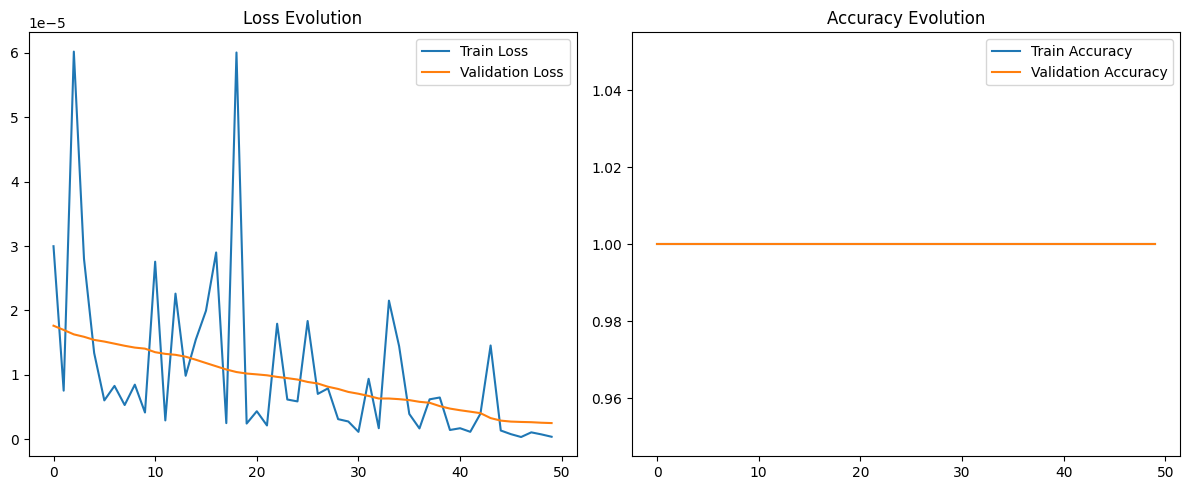

<Sequential name=sequential, built=True>

In [ ]:
keras_tuner_search()

In [ ]:
optuna_search()

[I 2025-06-07 00:42:36,458] A new study created in memory with name: no-name-c3ed1236-ab16-4547-9f72-b7f910d816c3
[W 2025-06-07 00:42:36,473] Trial 0 failed with parameters: {'units_1': 74, 'num_layers': 1, 'optimizer': 'sgd', 'lr': 0.00943145515989302, 'units_2': 99, 'dropout_2': 0.14907575698471648} because of the following error: AttributeError("'NoneType' object has no attribute 'Int'").
Traceback (most recent call last):
  File "d:\Programming\ML-labs\.venv\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Николай\AppData\Local\Temp\ipykernel_13084\2890579099.py", line 182, in objective
    model = build_model()
            ^^^^^^^^^^^^^
  File "C:\Users\Николай\AppData\Local\Temp\ipykernel_13084\2890579099.py", line 56, in build_model
    units=hp.Int(f'units_{i+2}', 32, 128, step=32, default=64),
          ^^^^^^
AttributeError: 'NoneType' object has no attribute 'Int'
[W 202


=== Optuna Search ===


AttributeError: 'NoneType' object has no attribute 'Int'